In [1]:
import os
import cv2
import math
import json
import random
import numpy as np
import pandas as pd

from PIL import Image

from random import seed
from torch import nn
from collections import defaultdict
from scipy.ndimage import label
from abc import abstractmethod
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score

from tqdm import tqdm
from IPython.display import Image as IPythonImage

In [2]:
# Update the root dataset directory based on the university server structure
DATASET_ROOT_DIR = '/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws'

# Define the directories for training and test images and masks
TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'train/struct_images')
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'train/struct_masks')
TRAIN_ANNOTATIONS_FILE = os.path.join(DATASET_ROOT_DIR, 'train/train_annotations.csv')
TRAIN_HASANOMALY_FILE = os.path.join(DATASET_ROOT_DIR, 'train/train_hasanomaly.csv')

TEST_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'test/struct_images')
TEST_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'test/struct_masks')
TEST_ANNOTATIONS_FILE = os.path.join(DATASET_ROOT_DIR, 'test/test_annotations.csv')
TEST_HASANOMALY_FILE = os.path.join(DATASET_ROOT_DIR, 'test/test_hasanomaly.csv')

# Print the updated paths
print(TRAIN_IMAGE_DIR)
print(TRAIN_MASK_DIR)
print(TRAIN_ANNOTATIONS_FILE)
print(TRAIN_HASANOMALY_FILE)

print(TEST_IMAGE_DIR)
print(TEST_MASK_DIR)
print(TEST_ANNOTATIONS_FILE)
print(TEST_HASANOMALY_FILE)

/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/train/struct_images
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/train/struct_masks
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/train/train_annotations.csv
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/train/train_hasanomaly.csv
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/test/struct_images
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/test/struct_masks
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/test/test_annotations.csv
/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws/test/test_hasanomaly.csv


In [3]:
class ScrewDataset(Dataset):
    def __init__(self, image_dir, mask_dir, annotations_file, anomaly_file, image_transform=None, mask_transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.annotations = pd.read_csv(annotations_file)
        self.anomalies = pd.read_csv(anomaly_file)
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.images = os.listdir(image_dir)        

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # Get the file name from annotations
        image_file = self.annotations.iloc[idx]['image_file']
        image_path = os.path.join(self.image_dir, f"{image_file}.png")
        mask_path = os.path.join(self.mask_dir, f"{image_file}.png")

        # Load the image, mask, count number and anomaly status
        image = Image.open(image_path).convert('RGB')
        #mask = Image.open(mask_path).convert('L')
        mask = Image.open(mask_path)
        has_anomaly = self.anomalies.iloc[idx]['has_anomaly']
        small_screw_count = self.annotations.iloc[idx]['small_screw_count']
        large_screw_count = self.annotations.iloc[idx]['large_screw_count']

        # Apply any necessary transforms
        if self.image_transform:
            image = self.image_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        # Return the image, mask, and counts
        return {
            'image': image,
            'mask': mask,
            'has_anomaly': torch.tensor(has_anomaly, dtype=torch.float),
            'small_screw_count': torch.tensor(small_screw_count, dtype=torch.float),
            'large_screw_count': torch.tensor(large_screw_count, dtype=torch.float)
        }
    
# Initialize dataset object
train_dataset = ScrewDataset( image_dir = TRAIN_IMAGE_DIR, mask_dir = TRAIN_MASK_DIR, annotations_file = TRAIN_ANNOTATIONS_FILE, anomaly_file = TRAIN_HASANOMALY_FILE)

# Get a sample from the dataset (e.g., the first sample)
sample = train_dataset[0]

# Print details about the sample
print(f"Image shape: {sample['image'].size}")  # Assuming PIL image
print(f"Mask shape: {sample['mask'].size}")    # Assuming PIL mask
print(f"Small screw count: {sample['small_screw_count']}")
print(f"Large screw count: {sample['large_screw_count']}")
print(f"Image has anomaly: {sample['has_anomaly']}")

Image shape: (512, 512)
Mask shape: (512, 512)
Small screw count: 3.0
Large screw count: 3.0
Image has anomaly: 1.0


Unique values in the mask: [0 1]


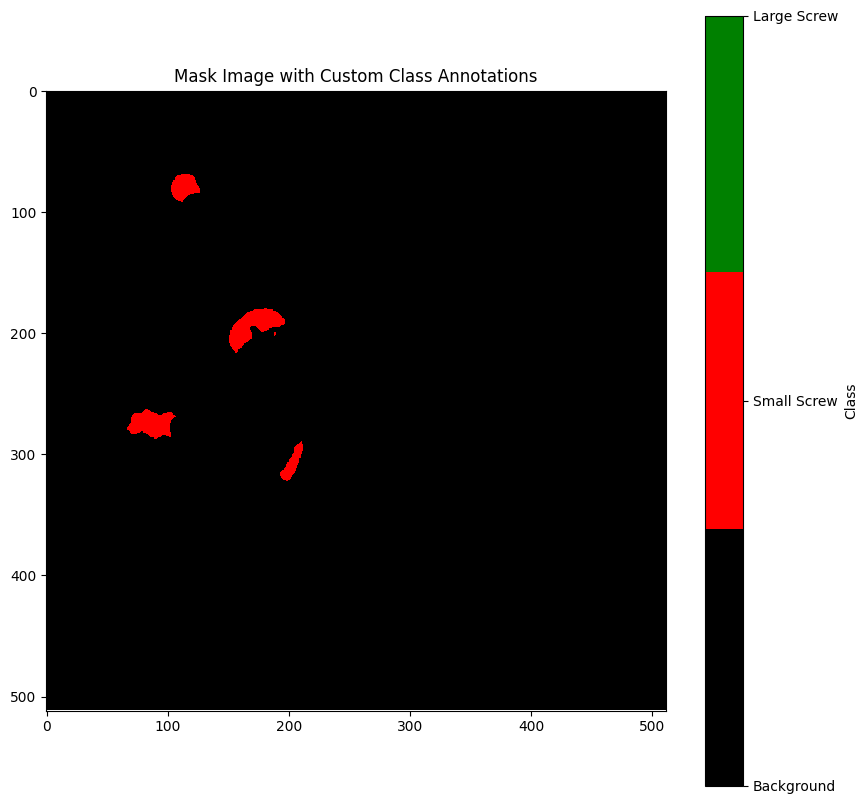

In [4]:
# Load the mask image
mask_path = os.path.join(TEST_MASK_DIR, 'image_0021.png')
#mask_path = os.path.join(TRAIN_MASK_DIR, 'image_0000.png')
mask = np.array(Image.open(mask_path))

# Check unique values in the mask
unique_values = np.unique(mask)
print("Unique values in the mask:", unique_values)

# Define custom colors for the classes: small screw, large screw, and background (ignore label)
colors = ['black', 'red', 'green']  # black for background, Red for small screw, green for large screw,
cmap = ListedColormap(colors)

# Display the mask image with the custom colormap
plt.figure(figsize=(10, 10))
plt.imshow(mask, cmap=cmap, vmin=0, vmax=2)
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Background', 'Small Screw', 'Large Screw'])  # Custom ticks and labels for the color bar
cbar.set_label('Class')
plt.title('Mask Image with Custom Class Annotations')
plt.show()

In [5]:
class SegmentationSubNetwork(nn.Module):
    """
    Segmentation Subnetwork for predicting anomaly masks and optionally integrating 
    counting-related features.
    """
    def __init__(self, in_channels=3, out_channels=3, use_fp16=False, base_channels=64, out_features=False):
        super(SegmentationSubNetwork, self).__init__()
        base_width = base_channels
        self.encoder_segment = EncoderSegmentation(in_channels, base_width)
        self.decoder_segment = DecoderSegmentation(base_width, out_channels=out_channels)
        self.out_features = out_features

    def forward(self, x, screw_count_features=None):
        """
        Forward pass that optionally integrates screw counting features into the segmentation process.
        """
        b1, b2, b3, b4, b5, b6 = self.encoder_segment(x)
        output_segment = self.decoder_segment(b1, b2, b3, b4, b5, b6)

        if screw_count_features is not None:
            # Integrate screw counting features (from the ViT or other sources) to assist in anomaly detection
            output_segment = output_segment + screw_count_features

        if self.out_features:
            return output_segment, b2, b3, b4, b5, b6
        else:
            return output_segment

class EncoderSegmentation(nn.Module):
    """
    Encoder part of the segmentation network that extracts features at multiple scales.
    """
    def __init__(self, in_channels, base_width):
        super(EncoderSegmentation, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width, base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True))
        self.mp1 = nn.Sequential(nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(base_width, base_width * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 2, base_width * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 2),
            nn.ReLU(inplace=True))
        self.mp2 = nn.Sequential(nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(base_width * 2, base_width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 4, base_width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 4),
            nn.ReLU(inplace=True))
        self.mp3 = nn.Sequential(nn.MaxPool2d(2))
        self.block4 = nn.Sequential(
            nn.Conv2d(base_width * 4, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True))
        self.mp4 = nn.Sequential(nn.MaxPool2d(2))
        self.block5 = nn.Sequential(
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True))

        self.mp5 = nn.Sequential(nn.MaxPool2d(2))
        self.block6 = nn.Sequential(
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True))

    def forward(self, x):
        """
        Pass input x through the encoder blocks to extract feature maps at multiple scales.
        """
        b1 = self.block1(x)
        mp1 = self.mp1(b1)
        b2 = self.block2(mp1)
        mp2 = self.mp2(b2)
        b3 = self.block3(mp2)
        mp3 = self.mp3(b3)
        b4 = self.block4(mp3)
        mp4 = self.mp4(b4)
        b5 = self.block5(mp4)
        mp5 = self.mp5(b5)
        b6 = self.block6(mp5)
        return b1, b2, b3, b4, b5, b6

class DecoderSegmentation(nn.Module):
    """
    Decoder part of the segmentation network that upscales feature maps and refines predictions.
    """
    def __init__(self, base_width, out_channels=1):  
        super(DecoderSegmentation, self).__init__()

        self.up_b = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1), 
                                 nn.BatchNorm2d(base_width * 8),
                                 nn.ReLU(inplace=True))
        
        self.db_b = nn.Sequential(
            nn.Conv2d(base_width * (8 + 8), base_width * 8, kernel_size=3, padding=1), 
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 8, base_width * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 8),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(base_width * 8, base_width * 4, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(base_width * 4),
                                 nn.ReLU(inplace=True))
        self.db1 = nn.Sequential(
            nn.Conv2d(base_width * (4 + 8), base_width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 4, base_width * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 4),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(base_width * 4, base_width * 2, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(base_width * 2),
                                 nn.ReLU(inplace=True))
        self.db2 = nn.Sequential(
            nn.Conv2d(base_width * (2 + 4), base_width * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width * 2, base_width * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width * 2),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(base_width * 2, base_width, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(base_width),
                                 nn.ReLU(inplace=True))
        self.db3 = nn.Sequential(
            nn.Conv2d(base_width * (2 + 1), base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width, base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True)
        )

        self.up4 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(base_width, base_width, kernel_size=3, padding=1),
                                 nn.BatchNorm2d(base_width),
                                 nn.ReLU(inplace=True))
        self.db4 = nn.Sequential(
            nn.Conv2d(base_width * 2, base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_width, base_width, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_width),
            nn.ReLU(inplace=True)
        )

        self.fin_out = nn.Sequential(nn.Conv2d(base_width, out_channels, kernel_size=3, padding=1),
                                     nn.Sigmoid())

    def forward(self, b1, b2, b3, b4, b5, b6):
        """
        Pass input feature maps through the decoder to produce segmentation masks.
        """
        up_b = self.up_b(b6)
        cat_b = torch.cat((up_b, b5), dim=1)
        db_b = self.db_b(cat_b)

        up1 = self.up1(db_b)
        cat1 = torch.cat((up1, b4), dim=1)
        db1 = self.db1(cat1)

        up2 = self.up2(db1)
        cat2 = torch.cat((up2, b3), dim=1)
        db2 = self.db2(cat2)

        up3 = self.up3(db2)
        cat3 = torch.cat((up3, b2), dim=1)
        db3 = self.db3(cat3)

        up4 = self.up4(db3)
        cat4 = torch.cat((up4, b1), dim=1)
        db4 = self.db4(cat4)

        out = self.fin_out(db4)
        return out

# Set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the input shape and other parameters
# input_channels = 6  # Since your input is concatenation of original image + predicted x_0 (3 + 3 channels)
# output_channels = 1  # The output mask has 1 channel
# image_height = 512  # Height of the input image
# image_width = 512   # Width of the input image

# Initialize the SegmentationSubNetwork
# segmentation_model = SegmentationSubNetwork(in_channels=input_channels, out_channels=output_channels).to(device)

# Create a dummy input tensor representing (batch_size, input_channels, height, width)
# dummy_input = torch.randn(1, input_channels, image_height, image_width).to(device)  # Batch size = 1

# Pass the dummy input through the segmentation model
# segmentation_output = segmentation_model(dummy_input)

# Print out the shape of the output to verify if it matches expected dimensions
# print(f"Input Shape: {dummy_input.shape}")
# print(f"Output Shape: {segmentation_output.shape}")

# Optionally check if the output values are within the expected range
# print(f"Output Min: {segmentation_output.min().item()}")
# print(f"Output Max: {segmentation_output.max().item()}")

# Additional Debugging: If screw count features are enabled in your model, you can try passing them as well
# Screw count features dummy tensor (Optional)
# dummy_screw_count_features = torch.randn_like(segmentation_output)  # Example, shape should match output mask

# Forward pass with screw count features
# segmentation_output_with_features = segmentation_model(dummy_input, screw_count_features=dummy_screw_count_features)

# Print out the output with screw count features to check
# print(f"Output Shape (with screw count features): {segmentation_output_with_features.shape}")

Input Shape: torch.Size([1, 6, 512, 512])
Output Shape: torch.Size([1, 1, 512, 512])
Output Min: 0.10019352287054062
Output Max: 0.8108215928077698
Output Shape (with screw count features): torch.Size([1, 1, 512, 512])


In [7]:
class TimestepBlock(nn.Module):
    """
    Any module where forward() takes timestep embeddings as a second argument.
    """

    @abstractmethod
    def forward(self, x, emb):
        """
        Apply the module to `x` given `emb` timestep embeddings.
        """

class TimestepEmbedSequential(nn.Sequential, TimestepBlock):
    """
    A sequential module that passes timestep embeddings to the children that
    support it as an extra input.
    """

    def forward(self, x, emb):
        for layer in self:
            if isinstance(layer, TimestepBlock):
                x = layer(x, emb)
            else:
                x = layer(x)
        return x

class PositionalEmbedding(nn.Module):
    """
    Computes Positional Embedding of the timestep.
    """

    def __init__(self, dim, scale=1):
        super().__init__()
        assert dim % 2 == 0
        self.dim = dim
        self.scale = scale

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = np.log(10000) / half_dim
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = torch.outer(x * self.scale, emb)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class Downsample(nn.Module):
    def __init__(self, in_channels, use_conv, out_channels=None):
        super().__init__()
        self.channels = in_channels
        out_channels = out_channels or in_channels
        if use_conv:
            # downsamples by 1/2
            self.downsample = nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1)
        else:
            assert in_channels == out_channels
            self.downsample = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x, time_embed=None):
        assert x.shape[1] == self.channels
        return self.downsample(x)

class Upsample(nn.Module):
    def __init__(self, in_channels, use_conv, out_channels=None):
        super().__init__()
        self.channels = in_channels
        self.use_conv = use_conv
        if use_conv:
            self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x, time_embed=None):
        assert x.shape[1] == self.channels
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        if self.use_conv:
            x = self.conv(x)
        return x

class AttentionBlock(nn.Module):
    """
    An attention block that allows spatial positions to attend to each other.
    """

    def __init__(self, in_channels, n_heads=1, n_head_channels=-1):
        super().__init__()
        self.in_channels = in_channels
        self.norm = GroupNorm32(32, self.in_channels)
        if n_head_channels == -1:
            self.num_heads = n_heads
        else:
            assert(in_channels % n_head_channels == 0),f"q,k,v channels {in_channels} is not divisible by num_head_channels {n_head_channels}"
            self.num_heads = in_channels // n_head_channels

        self.to_qkv = nn.Conv1d(in_channels, in_channels * 3, 1)
        self.attention = QKVAttention(self.num_heads)
        self.proj_out = zero_module(nn.Conv1d(in_channels, in_channels, 1))

    def forward(self, x, time=None):
        b, c, *spatial = x.shape
        x = x.reshape(b, c, -1)
        qkv = self.to_qkv(self.norm(x))
        h = self.attention(qkv)
        h = self.proj_out(h)
        return (x + h).reshape(b, c, *spatial)

class QKVAttention(nn.Module):
    def __init__(self, n_heads):
        super().__init__()
        self.n_heads = n_heads

    def forward(self, qkv, time=None):
        bs, width, length = qkv.shape
        assert width % (3 * self.n_heads) == 0
        ch = width // (3 * self.n_heads)
        q, k, v = qkv.reshape(bs * self.n_heads, ch * 3, length).split(ch, dim=1)
        scale = 1 / math.sqrt(math.sqrt(ch))
        weight = torch.einsum(
                "bct,bcs->bts", q * scale, k * scale
                )  # More stable with f16 than dividing afterwards
        weight = torch.softmax(weight.float(), dim=-1).type(weight.dtype)
        a = torch.einsum("bts,bcs->bct", weight, v)
        return a.reshape(bs, -1, length)

class ResBlock(TimestepBlock):
    def __init__(
            self,
            in_channels,
            time_embed_dim,
            dropout,
            out_channels=None,
            use_conv=False,
            up=False,
            down=False
            ):
        super().__init__()
        
        out_channels = out_channels or in_channels #My Change
        
        self.in_layers = nn.Sequential(
                GroupNorm32(32, in_channels),
                nn.SiLU(),
                nn.Conv2d(in_channels, out_channels, 3, padding=1)
                )
        self.updown = up or down

        if up:
            self.h_upd = Upsample(in_channels, False)
            self.x_upd = Upsample(in_channels, False)
        elif down:
            self.h_upd = Downsample(in_channels, False)
            self.x_upd = Downsample(in_channels, False)
        else:
            self.h_upd = self.x_upd = nn.Identity()

        self.embed_layers = nn.Sequential(
                nn.SiLU(),
                nn.Linear(time_embed_dim, out_channels)
                )
        self.out_layers = nn.Sequential(
                GroupNorm32(32, out_channels),
                nn.SiLU(),
                nn.Dropout(p=dropout),
                zero_module(nn.Conv2d(out_channels, out_channels, 3, padding=1))
                )
        if out_channels == in_channels:
            self.skip_connection = nn.Identity()
        elif use_conv:
            self.skip_connection = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        else:
            self.skip_connection = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x, time_embed):
        if self.updown:
            in_rest, in_conv = self.in_layers[:-1], self.in_layers[-1]
            h = in_rest(x)
            h = self.h_upd(h)
            x = self.x_upd(x)
            h = in_conv(h)
        else:
            h = self.in_layers(x)
        emb_out = self.embed_layers(time_embed).type(h.dtype)
        while len(emb_out.shape) < len(h.shape):
            emb_out = emb_out[..., None]

        h = h + emb_out
        h = self.out_layers(h)
        return self.skip_connection(x) + h

class UNetModel(nn.Module):
    """
    U-Net model for reconstruction with added support for screw counting.
    """
    def __init__(
            self,
            img_size,
            base_channels,
            conv_resample=True,
            n_heads=1,
            n_head_channels=-1,
            channel_mults="",
            num_res_blocks=2,
            dropout=0,
            attention_resolutions="32,16,8",
            biggan_updown=True,
            in_channels=1
            ):
        self.dtype = torch.float32
        super().__init__()

        if channel_mults == "":
            if img_size == 512:
                channel_mults = (1, 1, 2, 2, 4, 4)
            elif img_size == 256:
                channel_mults = (1, 1, 2, 2, 4, 4)
            elif img_size == 128:
                channel_mults = (1, 1, 2, 3, 4)
            elif img_size == 64:
                channel_mults = (1, 2, 3, 4)
            elif img_size == 32:
                channel_mults = (1, 2, 3, 4)
            else:
                raise ValueError(f"unsupported image size: {img_size}")
        attention_ds = []
        for res in attention_resolutions.split(","):
            attention_ds.append(img_size // int(res))

        self.image_size = img_size
        self.in_channels = in_channels
        self.model_channels = base_channels
        self.out_channels = in_channels
        self.num_res_blocks = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.dropout = dropout
        self.channel_mult = channel_mults
        self.conv_resample = conv_resample

        self.dtype = torch.float32
        self.num_heads = n_heads
        self.num_head_channels = n_head_channels

        time_embed_dim = base_channels * 4
        self.time_embedding = nn.Sequential(
                PositionalEmbedding(base_channels, 1),
                nn.Linear(base_channels, time_embed_dim),
                nn.SiLU(),
                nn.Linear(time_embed_dim, time_embed_dim),
                )

        ch = int(channel_mults[0] * base_channels)
        self.down = nn.ModuleList(
                [TimestepEmbedSequential(nn.Conv2d(self.in_channels, base_channels, 3, padding=1))]
                )
        channels = [ch]
        ds = 1
        for i, mult in enumerate(channel_mults):
            for _ in range(num_res_blocks):
                layers = [ResBlock(
                        ch,
                        time_embed_dim=time_embed_dim,
                        out_channels=base_channels * mult,
                        dropout=dropout,
                        )]
                ch = base_channels * mult

                if ds in attention_ds:
                    layers.append(
                            AttentionBlock(
                                    ch,
                                    n_heads=n_heads,
                                    n_head_channels=n_head_channels,
                                    )
                            )
                self.down.append(TimestepEmbedSequential(*layers))
                channels.append(ch)
            if i != len(channel_mults) - 1:
                out_channels = ch
                self.down.append(
                        TimestepEmbedSequential(
                                ResBlock(
                                        ch,
                                        time_embed_dim=time_embed_dim,
                                        out_channels=out_channels,
                                        dropout=dropout,
                                        down=True
                                        )
                                if biggan_updown
                                else
                                Downsample(ch, conv_resample, out_channels=out_channels)
                                )
                        )
                ds *= 2
                ch = out_channels
                channels.append(ch)

        self.middle = TimestepEmbedSequential(
                ResBlock(
                        ch,
                        time_embed_dim=time_embed_dim,
                        dropout=dropout
                        ),
                AttentionBlock(
                        ch,
                        n_heads=n_heads,
                        n_head_channels=n_head_channels
                        ),
                ResBlock(
                        ch,
                        time_embed_dim=time_embed_dim,
                        dropout=dropout
                        )
                )
        self.up = nn.ModuleList([])

        for i, mult in reversed(list(enumerate(channel_mults))):
            for j in range(num_res_blocks + 1):
                inp_chs = channels.pop()
                layers = [
                    ResBlock(
                            ch + inp_chs,
                            time_embed_dim=time_embed_dim,
                            out_channels=base_channels * mult,
                            dropout=dropout
                            )
                    ]
                ch = base_channels * mult
                if ds in attention_ds:
                    layers.append(
                            AttentionBlock(
                                    ch,
                                    n_heads=n_heads,
                                    n_head_channels=n_head_channels
                                    ),
                            )

                if i and j == num_res_blocks:
                    out_channels = ch
                    layers.append(
                            ResBlock(
                                    ch,
                                    time_embed_dim=time_embed_dim,
                                    out_channels=out_channels,
                                    dropout=dropout,
                                    up=True
                                    )
                            if biggan_updown
                            else
                            Upsample(ch, conv_resample, out_channels=out_channels)
                            )
                    ds //= 2
                self.up.append(TimestepEmbedSequential(*layers))

        self.out = nn.Sequential(
                GroupNorm32(32, ch),
                nn.SiLU(),
                zero_module(nn.Conv2d(base_channels * channel_mults[0], self.out_channels, 3, padding=1))
                )

    def forward(self, x, time):
        """
        Forward method that incorporates counting features for small and large screws.
        """
        time_embed = self.time_embedding(time)

        skips = []

        h = x.type(self.dtype)
        for i, module in enumerate(self.down):
            h = module(h, time_embed)
            skips.append(h)

        h = self.middle(h, time_embed)

        # Screw count features can be extracted from here and used for ViT counting
        screw_count_features = h

        for i, module in enumerate(self.up):
            h = torch.cat([h, skips.pop()], dim=1)
            h = module(h, time_embed)

        h = h.type(x.dtype)
        h = self.out(h)

        return h, screw_count_features

class GroupNorm32(nn.GroupNorm):
    def forward(self, x):
        return super().forward(x.float()).type(x.dtype)

def zero_module(module):
    """
    Zero out the parameters of a module and return it.
    """
    for p in module.parameters():
        p.detach().zero_()
    return module

def update_ema_params(target, source, decay_rate=0.9999):
    targParams = dict(target.named_parameters())
    srcParams = dict(source.named_parameters())
    for k in targParams:
        targParams[k].data.mul_(decay_rate).add_(srcParams[k].data, alpha=1 - decay_rate)

if __name__ == "__main__":
    # Example usage
    args = {
        'img_size':          512,
        'base_channels':     64,
        'dropout':           0.3,
        'num_heads':         4,
        'num_head_channels': '32,16,8',
        'lr':                1e-4,
        'Batch_Size':        64
        }
    model = UNetModel(
            args['img_size'], args['base_channels'], dropout=args[
                "dropout"], n_heads=args["num_heads"], attention_resolutions=args["num_head_channels"],
            in_channels=3
            )

    x = torch.randn(1, 3, 512, 512)
    t_batch = torch.tensor([1], device=x.device).repeat(x.shape[0])
    h, screw_count_features = model(x, t_batch)
    print(h.shape)
    print(screw_count_features.shape)


torch.Size([1, 3, 512, 512])
torch.Size([1, 256, 16, 16])


In [8]:
# ViT for counting anomaly detection
class ViTCountingAnomaly(nn.Module):
    def __init__(self, image_size=256, patch_size=16, dim=512, depth=6, heads=8, mlp_dim=1024):
        super(ViTCountingAnomaly, self).__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size."

        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * 3

        self.patch_embedding = nn.Linear(self.patch_dim, dim)

        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        
        self.transformer = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=dim, nhead=heads, dim_feedforward=mlp_dim
            ) for _ in range(depth)
        ])
        
        self.to_cls_token = nn.Identity()

        # Two separate outputs: one for small screws and one for large screws
        self.mlp_head_small = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, 1)  # Predicts count for small screws
        )

        self.mlp_head_large = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, 1)  # Predicts count for large screws
        )

    def forward(self, x):
        B, C, H, W = x.shape
        patches = x.unfold(2, 16, 16).unfold(3, 16, 16)
        patches = patches.contiguous().view(B, -1, 16 * 16 * C)
        
        tokens = self.patch_embedding(patches)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, tokens), dim=1)
        x += self.pos_embedding

        for transformer_layer in self.transformer:
            x = transformer_layer(x)

        x = self.to_cls_token(x[:, 0])
        
        # Predict counts for small and large screws separately
        small_screw_count = self.mlp_head_small(x)
        large_screw_count = self.mlp_head_large(x)

        return small_screw_count, large_screw_count

# Gaussian diffusion-related functions
def get_beta_schedule(num_diffusion_steps, name="cosine"):
    betas = []
    if name == "cosine":
        max_beta = 0.999
        f = lambda t: np.cos((t + 0.008) / 1.008 * np.pi / 2) ** 2
        for i in range(num_diffusion_steps):
            t1 = i / num_diffusion_steps
            t2 = (i + 1) / num_diffusion_steps
            betas.append(min(1 - f(t2) / f(t1), max_beta))
        betas = np.array(betas)
    elif name == "linear":
        scale = 1000 / num_diffusion_steps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        betas = np.linspace(beta_start, beta_end, num_diffusion_steps, dtype=np.float64)
    else:
        raise NotImplementedError(f"unknown beta schedule: {name}")
    return betas

def extract(arr, timesteps, broadcast_shape, device):
    res = torch.from_numpy(arr).to(device=timesteps.device)[timesteps].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]
    return res.expand(broadcast_shape).to(device)

def mean_flat(tensor):
    return torch.mean(tensor, dim=list(range(1, len(tensor.shape))))

def normal_kl(mean1, logvar1, mean2, logvar2):
    """
    Compute the KL Divergence between two gaussians.
    """
    return 0.5 * (-1 + logvar2 - logvar1 + torch.exp(logvar1 - logvar2) + ((mean1 - mean2) ** 2) * torch.exp(-logvar2))

def approx_standard_normal_cdf(x):
    return 0.5 * (1.0 + torch.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * torch.pow(x, 3))))

def discretised_gaussian_log_likelihood(x, means, log_scales):
    """
    Compute the log-likelihood of a Gaussian distribution discretizing to a
    given image.
    """
    assert x.shape == means.shape == log_scales.shape
    centered_x = x - means
    inv_stdv = torch.exp(-log_scales)
    plus_in = inv_stdv * (centered_x + 1.0 / 255.0)
    cdf_plus = approx_standard_normal_cdf(plus_in)

    min_in = inv_stdv * (centered_x - 1.0 / 255.0)
    cdf_min = approx_standard_normal_cdf(min_in)

    log_cdf_plus = torch.log(cdf_plus.clamp(min=1e-12))
    log_one_minus_cdf_min = torch.log((1.0 - cdf_min).clamp(min=1e-12))

    cdf_delta = cdf_plus - cdf_min
    log_probs = torch.where(
            x < -0.999,
            log_cdf_plus,
            torch.where(x > 0.999, log_one_minus_cdf_min, torch.log(cdf_delta.clamp(min=1e-12))),
            )
    assert log_probs.shape == x.shape
    return log_probs

class GaussianDiffusionModel:
    def __init__(
            self,
            img_size,
            betas,
            img_channels=1,
            loss_type="l2",  # l2, l1, hybrid
            loss_weight='none',  # prop t / uniform / None
            noise="gauss",  # gauss / perlin / simplex
            ):
        super().__init__()

        if noise == "gauss":
            self.noise_fn = lambda x, t: torch.randn_like(x)

        self.img_size = img_size
        self.img_channels = img_channels
        self.loss_type = loss_type
        self.num_timesteps = len(betas)

        if loss_weight == 'prop-t':
            self.weights = np.arange(self.num_timesteps, 0, -1)
        elif loss_weight == "uniform":
            self.weights = np.ones(self.num_timesteps)

        self.loss_weight = loss_weight
        alphas = 1 - betas
        self.betas = betas
        self.sqrt_alphas = np.sqrt(alphas)
        self.sqrt_betas = np.sqrt(betas)

        self.alphas_cumprod = np.cumprod(alphas, axis=0)
        self.alphas_cumprod_prev = np.append(1.0, self.alphas_cumprod[:-1])

        # calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = np.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = np.sqrt(1.0 - self.alphas_cumprod)
        self.log_one_minus_alphas_cumprod = np.log(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = np.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = np.sqrt(1.0 / self.alphas_cumprod - 1)

        # posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
                betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_log_variance_clipped = np.log(
                np.append(self.posterior_variance[1], self.posterior_variance[1:])
                )
        self.posterior_mean_coef1 = (
                betas * np.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
                (1.0 - self.alphas_cumprod_prev)
                * np.sqrt(alphas)
                / (1.0 - self.alphas_cumprod)
        )

        self.gauss_blur = T.GaussianBlur(kernel_size=31, sigma=3)

    def sample_t_with_weights(self, b_size, device):
        p = self.weights / np.sum(self.weights)
        indices_np = np.random.choice(len(p), size=b_size, p=p)
        indices = torch.from_numpy(indices_np).long().to(device)
        weights_np = 1 / len(p) * p[indices_np]
        weights = torch.from_numpy(weights_np).float().to(device)
        return indices, weights

    def predict_x_0_from_eps(self, x_t, t, eps):
        return (extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape, x_t.device) * x_t
                - extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape, x_t.device) * eps)

    def predict_eps_from_x_0(self, x_t, t, pred_x_0):
        return (extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape, x_t.device) * x_t
                - pred_x_0) \
               / extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape, x_t.device)

    def q_mean_variance(self, x_0, t):
        mean = (
                extract(self.sqrt_alphas_cumprod, t, x_0.shape, x_0.device) * x_0
        )
        variance = extract(1.0 - self.alphas_cumprod, t, x_0.shape, x_0.device)
        log_variance = extract(
                self.log_one_minus_alphas_cumprod, t, x_0.shape, x_0.device
                )
        return mean, variance, log_variance

    def q_posterior_mean_variance(self, x_0, x_t, t):
        posterior_mean = (extract(self.posterior_mean_coef1, t, x_t.shape, x_t.device) * x_0
                          + extract(self.posterior_mean_coef2, t, x_t.shape, x_t.device) * x_t)

        posterior_var = extract(self.posterior_variance, t, x_t.shape, x_t.device)
        posterior_log_var_clipped = extract(self.posterior_log_variance_clipped, t, x_t.shape, x_t.device)
        return posterior_mean, posterior_var, posterior_log_var_clipped

    def p_mean_variance(self, model, x_t, t, estimate_noise=None):
        if estimate_noise is None:
            estimate_noise = model(x_t, t)

        model_var = np.append(self.posterior_variance[1], self.betas[1:])
        model_logvar = np.log(model_var)
        model_var = extract(model_var, t, x_t.shape, x_t.device)
        model_logvar = extract(model_logvar, t, x_t.shape, x_t.device)

        pred_x_0 = self.predict_x_0_from_eps(x_t, t, estimate_noise).clamp(-1, 1)
        model_mean, _, _ = self.q_posterior_mean_variance(pred_x_0, x_t, t)
        return {
            "mean":         model_mean,
            "variance":     model_var,
            "log_variance": model_logvar,
            "pred_x_0":     pred_x_0,
            }

    def sample_p(self, model, x_t, t, denoise_fn="gauss"):
        out = self.p_mean_variance(model, x_t, t)
        if denoise_fn == "gauss":
            noise = torch.randn_like(x_t)
        else:
            noise = denoise_fn(x_t, t)

        nonzero_mask = (
            (t != 0).float().view(-1, *([1] * (len(x_t.shape) - 1)))
        )

        sample = out["mean"] + nonzero_mask * torch.exp(0.5 * out["log_variance"]) * noise
        return {"sample": sample, "pred_x_0": out["pred_x_0"]}

    def forward_backward(
            self, model, vit_model, x, see_whole_sequence="half", t_distance=None, denoise_fn="gauss", screw_count_labels=None):
        """
        Forward-backward process with additional counting anomaly detection using ViT.
        """
        assert see_whole_sequence in ["whole", "half", None]

        if t_distance == 0:
            return x.detach()

        if t_distance is None:
            t_distance = self.num_timesteps

        seq = [x.cpu().detach()]
        if see_whole_sequence == "whole":
            for t in range(int(t_distance)):
                t_batch = torch.tensor([t], device=x.device).repeat(x.shape[0])
                noise = self.noise_fn(x, t_batch).float()
                with torch.no_grad():
                    x = self.sample_q_gradual(x, t_batch, noise)

                seq.append(x.cpu().detach())
        else:
            t_tensor = torch.tensor([t_distance - 1], device=x.device).repeat(x.shape[0])
            x = self.sample_q(x, t_tensor, self.noise_fn(x, t_tensor).float())
            if see_whole_sequence == "half":
                seq.append(x.cpu().detach())

        for t in range(int(t_distance) - 1, -1, -1):
            t_batch = torch.tensor([t], device=x.device).repeat(x.shape[0])
            with torch.no_grad():
                out = self.sample_p(model, x, t_batch, denoise_fn)
                x = out["sample"]

            if see_whole_sequence:
                seq.append(x.cpu().detach())

        # Add ViT-based counting for anomaly detection
        pred_small_count, pred_large_count = vit_model(x)
        counting_loss = self.compute_counting_loss(pred_small_count, pred_large_count, screw_count_labels)

        return x.detach() if not see_whole_sequence else seq, counting_loss

    def compute_counting_loss(self, pred_small_count, pred_large_count, true_counts):
        """
        Computes the counting loss for small and large screws.
        """
        mse_loss = nn.MSELoss()
        small_count_loss = mse_loss(pred_small_count, true_counts['small_screws'])
        large_count_loss = mse_loss(pred_large_count, true_counts['large_screws'])
        return small_count_loss + large_count_loss
        
    def sample_q(self, x_0, t, noise):
        """
            q (x_t | x_0 )

            :param x_0:
            :param t:
            :param noise:
            :return:
        """
        return (extract(self.sqrt_alphas_cumprod, t, x_0.shape, x_0.device) * x_0 +
                extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape, x_0.device) * noise)

    def sample_q_gradual(self, x_t, t, noise):
        """
        q (x_t | x_{t-1})
        :param x_t:
        :param t:
        :param noise:
        :return:
        """
        return (extract(self.sqrt_alphas, t, x_t.shape, x_t.device) * x_t +
                extract(self.sqrt_betas, t, x_t.shape, x_t.device) * noise)

    def calc_vlb_xt(self, model, x_0, x_t, t, estimate_noise=None):
        # find KL divergence at t
        true_mean, _, true_log_var = self.q_posterior_mean_variance(x_0, x_t, t)
        output = self.p_mean_variance(model, x_t, t, estimate_noise)
        kl = normal_kl(true_mean, true_log_var, output["mean"], output["log_variance"])
        kl = mean_flat(kl) / np.log(2.0)

        decoder_nll = -discretised_gaussian_log_likelihood(
                x_0, output["mean"], log_scales=0.5 * output["log_variance"]
                )
        decoder_nll = mean_flat(decoder_nll) / np.log(2.0)

        nll = torch.where((t == 0), decoder_nll, kl)
        return {"output": nll, "pred_x_0": output["pred_x_0"]}
    
    def calc_loss(self, model, x_0, t):
        noise = self.noise_fn(x_0, t).float()
        x_t = self.sample_q(x_0, t, noise)
        estimate_noise = model(x_t, t)
        loss = {}
        if self.loss_type == "l1":
            loss["loss"] = mean_flat((estimate_noise - noise).abs())
        elif self.loss_type == "l2":
            loss["loss"] = mean_flat((estimate_noise - noise).square())
        elif self.loss_type == "hybrid":
            loss["loss"] = mean_flat((estimate_noise - noise).square())
        else:
            loss["loss"] = mean_flat((estimate_noise - noise).square())
        return loss, x_t, estimate_noise

    # Other methods from the original code (e.g., norm_guided_one_step_denoising) remain unchanged.
    def norm_guided_one_step_denoising(self, model, x_0, anomaly_label,args):
        # two-scale t
        normal_t = torch.randint(0, args["less_t_range"], (x_0.shape[0],),device=x_0.device)
        noisier_t = torch.randint(args["less_t_range"],self.num_timesteps,(x_0.shape[0],),device=x_0.device)
        
        normal_loss, x_normal_t, estimate_noise_normal = self.calc_loss(model, x_0, normal_t)
        noisier_loss, x_noiser_t, estimate_noise_noisier = self.calc_loss(model, x_0, noisier_t)
        
        pred_x_0_noisier = self.predict_x_0_from_eps(x_noiser_t, noisier_t, estimate_noise_noisier).clamp(-1, 1)
        pred_x_t_noisier = self.sample_q(pred_x_0_noisier, normal_t, estimate_noise_normal)   

        # Only calculate the noise loss of normal samples according to formula 9.
        loss = (normal_loss["loss"]+noisier_loss["loss"])[anomaly_label==0].mean()
        # When the batch size is small, it may lead to an entire batch consisting solely of abnormal samples
        # If they are all abnormal samples, set loss to 0.
        if torch.isnan(loss):
            loss.fill_(0.0)

        estimate_noise_hat = estimate_noise_normal - extract(self.sqrt_one_minus_alphas_cumprod, normal_t, x_normal_t.shape, x_0.device) * args["condition_w"] * (pred_x_t_noisier-x_normal_t)
        pred_x_0_norm_guided = self.predict_x_0_from_eps(x_normal_t, normal_t, estimate_noise_hat).clamp(-1, 1)

        return loss,pred_x_0_norm_guided,normal_t,x_normal_t,x_noiser_t


    def norm_guided_one_step_denoising_eval(self, model, x_0, normal_t,noisier_t,args):

        normal_loss, x_normal_t, estimate_noise_normal = self.calc_loss(model, x_0, normal_t)
        noisier_loss, x_noisier_t, estimate_noise_noisier = self.calc_loss(model, x_0, noisier_t)

        pred_x_0_noisier = self.predict_x_0_from_eps(x_noisier_t, noisier_t, estimate_noise_noisier).clamp(-1, 1)
        pred_x_t_noisier = self.sample_q(pred_x_0_noisier, normal_t, estimate_noise_normal)    

        loss = (normal_loss["loss"]+noisier_loss["loss"]).mean()
        pred_x_0_normal = self.predict_x_0_from_eps(x_normal_t, normal_t, estimate_noise_normal).clamp(-1, 1)
        estimate_noise_hat = estimate_noise_normal - extract(self.sqrt_one_minus_alphas_cumprod, normal_t, x_0.shape, x_0.device) * args["condition_w"] * (pred_x_t_noisier-x_normal_t)
        pred_x_0_norm_guided = self.predict_x_0_from_eps(x_normal_t, normal_t, estimate_noise_hat).clamp(-1, 1)
        
        return loss,pred_x_0_norm_guided,pred_x_0_normal,pred_x_0_noisier,x_normal_t,x_noisier_t,pred_x_t_noisier  
    
    def noise_t(self, model, x_0, t,args):
        loss, x_t, estimate_noise = self.calc_loss(model, x_0, t)
        loss = (loss["loss"] ).mean()
        pred_x_0 = self.predict_x_0_from_eps(x_t, t, estimate_noise).clamp(-1, 1)
        return loss,pred_x_0,x_t

In [10]:
# Verify the ViTCountingAnomaly class
if __name__ == "__main__":
    # Set up parameters
    image_size = 512
    patch_size = 16
    dim = 512
    depth = 6
    heads = 8
    mlp_dim = 1024

    # Create a ViTCountingAnomaly model
    model = ViTCountingAnomaly(image_size=image_size, patch_size=patch_size, dim=dim, depth=depth, heads=heads, mlp_dim=mlp_dim)

    # Create a dummy input (batch_size, channels, height, width)
    dummy_input = torch.randn(1, 3, image_size, image_size)  # Batch size 1, 3-channel image of 256x256

    # Run the model
    small_screw_count, large_screw_count = model(dummy_input)

    # Verify the outputs
    print("Predicted small screw count:", small_screw_count.item())
    print("Predicted large screw count:", large_screw_count.item())

    # Check output shapes
    print("Shape of small screw count:", small_screw_count.shape)  # Should be [1, 1]
    print("Shape of large screw count:", large_screw_count.shape)  # Should be [1, 1]

Predicted small screw count: 0.1035417914390564
Predicted large screw count: -0.17760896682739258
Shape of small screw count: torch.Size([1, 1])
Shape of large screw count: torch.Size([1, 1])


In [ ]:
# Custom loss for counting anomaly
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=4, logits=False, reduce=True):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce

    def forward(self, inputs, targets):
        if self.logits:
            BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        else:
            BCE_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss

In [11]:
def eval(testing_dataset_loader, args, unet_model, ddpm_sample, seg_model, vit_model, data_len, sub_class, device):
    unet_model.eval()
    seg_model.eval()
    vit_model.eval()

    total_image_pred = np.array([])
    total_image_gt = np.array([])
    total_pixel_gt = np.array([])
    total_pixel_pred = np.array([])
    tbar = tqdm(testing_dataset_loader)
    
    for i, sample in enumerate(tbar):
        image = sample["image"].to(device)
        target = sample['has_anomaly'].to(device)
        gt_mask = sample["mask"].to(device)
        small_screw_count = sample['small_screw_count'].to(device)
        large_screw_count = sample['large_screw_count'].to(device)

        normal_t_tensor = torch.tensor([args["eval_normal_t"]], device=image.device).repeat(image.shape[0])
        noiser_t_tensor = torch.tensor([args["eval_noisier_t"]], device=image.device).repeat(image.shape[0])

        # Perform structural anomaly detection
        loss, pred_x_0_condition, pred_x_0_normal, pred_x_0_noisier, x_normal_t, x_noiser_t, pred_x_t_noisier = ddpm_sample.norm_guided_one_step_denoising_eval(
            unet_model, image, normal_t_tensor, noiser_t_tensor, args)
        
        pred_mask = seg_model(torch.cat((image, pred_x_0_condition), dim=1))
        
        # Predict screw counts using ViT
        pred_small_screw_count, pred_large_screw_count = vit_model(image)

        # Evaluate image and pixel level anomalies
        flatten_pred_mask = pred_mask[0].flatten().detach().cpu().numpy()
        flatten_gt_mask = gt_mask[0].flatten().detach().cpu().numpy().astype(int)

        total_pixel_gt = np.append(total_pixel_gt, flatten_gt_mask)
        total_pixel_pred = np.append(total_pixel_pred, flatten_pred_mask)

    # Calculate AUROC for image and pixel-level anomalies
    auroc_pixel = round(roc_auc_score(total_pixel_gt, total_pixel_pred), 3) * 100
    print(f"Pixel AUROC: {auroc_pixel}")
    return auroc_pixel

In [12]:
def calculate_iou(pred_mask, gt_mask, threshold=0.5):
    # Convert predictions to binary (0 or 1) by thresholding
    pred_mask = (pred_mask > threshold).float()
    gt_mask = (gt_mask > threshold).float()

    # Ensure that both masks are boolean or integer for bitwise operations
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()

    # Calculate intersection and union
    intersection = (pred_mask & gt_mask).float().sum((1, 2))  # AND operation
    union = (pred_mask | gt_mask).float().sum((1, 2))         # OR operation

    # Calculate IoU (Intersection over Union)
    iou = (intersection + 1e-6) / (union + 1e-6)  # Add small epsilon to prevent division by zero
    return iou.mean().item()  # Return the mean IoU across the batch

In [14]:
def save_models(unet_model, seg_model, vit_model, args, final, epoch, sub_class):
    """
    Save the models (U-Net, Segmentation, and ViT).
    """
    os.makedirs(f'{args["output_path"]}/model/diff-params-ARGS={args["arg_num"]}/{sub_class}', exist_ok=True)
    torch.save(
        {
            'n_epoch': epoch,
            'unet_model_state_dict': unet_model.state_dict(),
            'seg_model_state_dict': seg_model.state_dict(),
            'vit_model_state_dict': vit_model.state_dict(),
            "args": args
        }, f'{args["output_path"]}/model/diff-params-ARGS={args["arg_num"]}/{sub_class}/params-{final}.pt'
    )

In [13]:
def weights_init(m):
  classname = m.__class__.__name__
  if classname.find('Conv') != -1:
    m.weight.data.normal_(0.0, 0.02)
  elif classname.find('BatchNorm') != -1:
    m.weight.data.normal_(1.0, 0.02)
    m.bias.data.fill_(0)

#del images, labels, noise_loss, pred_x0  # Or other variables you no longer need
torch.cuda.empty_cache()

In [ ]:
def train(training_dataset_loader, testing_dataset_loader, testing_dataset_len, args, device):
    in_channels = args["channels"]
    unet_model = UNetModel(args['img_size'][0], args['base_channels'], channel_mults=args['channel_mults'],
                           dropout=args["dropout"], n_heads=args["num_heads"], n_head_channels=args["num_head_channels"],
                           in_channels=in_channels).to(device)

    betas = get_beta_schedule(1000, 'linear')
    ddpm_sample = GaussianDiffusionModel(args['img_size'][0], betas, loss_weight='none', loss_type=args['loss_type'], noise=args['noise_fn'], img_channels=in_channels)
    seg_model = SegmentationSubNetwork(in_channels=6, out_channels=1).to(device)

    # Vision Transformer for counting anomalies (ViTCountingAnomaly)
    vit_model = ViTCountingAnomaly(image_size=args['img_size'][0], patch_size=16).to(device)

    # Optimizers
    optimizer_ddpm = optim.Adam(unet_model.parameters(), lr=args['diffusion_lr'], weight_decay=args['weight_decay'])
    optimizer_seg = optim.Adam(seg_model.parameters(), lr=args['seg_lr'], weight_decay=args['weight_decay'])
    optimizer_vit = optim.Adam(vit_model.parameters(), lr=args['vit_lr'], weight_decay=args['weight_decay'])

    # Loss functions
    mse_loss = nn.MSELoss()
    loss_focal = BinaryFocalLoss().to(device)
    loss_smL1 = nn.SmoothL1Loss().to(device)

    # Scheduler
    scheduler_seg = optim.lr_scheduler.CosineAnnealingLR(optimizer_seg, T_max=10, eta_min=0, verbose=False)

    tqdm_epoch = range(0, args['EPOCHS'])
    
    best_image_auroc = 0.0
    best_pixel_auroc = 0.0
    best_iou = 0.0
    best_epoch = 0

    for epoch in tqdm_epoch:
        unet_model.train()
        seg_model.train()
        vit_model.train()
        
        train_loss = 0.0
        train_focal_loss = 0.0
        train_smL1_loss = 0.0
        train_noise_loss = 0.0
        train_count_loss = 0.0

        tbar = tqdm(training_dataset_loader)
        
        for i, sample in enumerate(tbar):
            aug_image = sample['image'].to(device)
            anomaly_mask = sample['mask'].to(device)
            anomaly_label = sample['has_anomaly'].to(device).squeeze()
            small_screw_count = sample['small_screw_count'].to(device)
            large_screw_count = sample['large_screw_count'].to(device)

            # Structural anomaly detection using DDPM and U-Net
            noise_loss, pred_x0, normal_t, x_normal_t, x_noiser_t = ddpm_sample.norm_guided_one_step_denoising(
                unet_model, aug_image, anomaly_label, args)

            # Segment anomaly using segmentation network
            pred_mask = seg_model(torch.cat((aug_image, pred_x0), dim=1))

            # Count anomalies using ViT (small and large screw counts)
            pred_small_screw_count, pred_large_screw_count = vit_model(aug_image)

            # Calculate losses
            focal_loss = loss_focal(pred_mask, anomaly_mask)
            smL1_loss = loss_smL1(pred_mask, anomaly_mask)
            small_screw_loss = mse_loss(pred_small_screw_count, small_screw_count)
            large_screw_loss = mse_loss(pred_large_screw_count, large_screw_count)
            count_loss = small_screw_loss + large_screw_loss

            # Total loss: Structural anomaly + segmentation loss + counting loss
            total_loss = noise_loss + 5 * focal_loss + smL1_loss + count_loss

            # Backpropagation
            optimizer_ddpm.zero_grad()
            optimizer_seg.zero_grad()
            optimizer_vit.zero_grad()

            total_loss.backward()

            optimizer_ddpm.step()
            optimizer_seg.step()
            optimizer_vit.step()

            scheduler_seg.step()

            train_loss += total_loss.item()
            train_smL1_loss += smL1_loss.item()
            train_focal_loss += 5 * focal_loss.item()
            train_noise_loss += noise_loss.item()
            train_count_loss += count_loss.item()

            tbar.set_description(f'Epoch: {epoch}, Train Loss: {train_loss:.3f}')

        # Evaluate and save best models periodically
        if (epoch + 1) % 2 == 0 and epoch > 0:
            temp_image_auroc, temp_pixel_auroc = eval(testing_dataset_loader, args, unet_model, ddpm_sample, seg_model, vit_model, data_len, device)
            iou_score = calculate_iou(pred_mask, anomaly_mask)

            tqdm.write(f'Epoch {epoch}: Temp_Image_AUROC: {temp_image_auroc}')
            tqdm.write(f'Epoch {epoch}: Temp_Pixel_AUROC: {temp_pixel_auroc}')
            tqdm.write(f'Epoch {epoch}: IOU_SCORE: {iou_score}')

            if (temp_image_auroc + temp_pixel_auroc) >= (best_image_auroc + best_pixel_auroc):
                if temp_image_auroc >= best_image_auroc:
                    save_models(unet_model, seg_model, vit_model, args, 'best', epoch)
                    best_image_auroc = temp_image_auroc
                    best_pixel_auroc = temp_pixel_auroc
                    best_iou = iou_score
                    best_epoch = epoch

    save_models(unet_model, seg_model, vit_model, args, 'last', epoch)
    print(best_epoch)
    print(best_iou)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    args = {
        "img_size": [512,512],
        "Batch_Size": 4,
        "EPOCHS": 3000,
        "T": 1000,
        "base_channels": 128,
        "beta_schedule": "linear",
        "loss_type": "l2",
        "diffusion_lr": 1e-4,
        "seg_lr": 1e-5,
        "random_slice":True,
        "weight_decay": 0.0,
        "save_imgs": True,
        "save_vids":False, 
        "dropout":0,
        "attention_resolutions":"32,16,8",
        "num_heads":4,
        "num_head_channels":-1,
        "noise_fn":"gauss",
        "channels":3,
        "mvtec_root_path":"datasets/mvtec",
        "visa_root_path":"datasets/VisA_1class/1cls",
        "dagm_root_path":"datasets/dagm",
        "mpdd_root_path":"datasets/mpdd",
        "anomaly_source_path":"datasets/DTD",
        "noisier_t_range":600,
        "less_t_range":300,
        "condition_w":1,
        "eval_normal_t":200,
        "eval_noisier_t":400,
        "output_path":"outputs"
    }

    # Custom mask transformation to ensure values remain unchanged
    def mask_to_tensor(mask_image):
        mask_array = np.array(mask_image)
        mask_tensor = torch.tensor(mask_array, dtype=torch.long)
        mask_tensor = mask_tensor.unsqueeze(0)
        return mask_tensor

    # Define the transformations
    image_transform = transforms.Compose([
        transforms.ToTensor(),
        ])

    mask_transform = transforms.Compose([
        transforms.Lambda(mask_to_tensor)
    ])

    training_dataset = ScrewDataset(image_dir=TRAIN_IMAGE_DIR, mask_dir=TRAIN_MASK_DIR, annotations_file = TRAIN_ANNOTATIONS_FILE, image_transform=image_transform, mask_transform=mask_transform)
    training_dataset_loader = DataLoader(training_dataset, batch_size=2,drop_last=True)

    testing_dataset = ScrewDataset(image_dir=TEST_IMAGE_DIR, mask_dir=TEST_MASK_DIR, annotations_file= TEST_ANNOTATIONS_FILE, image_transform=image_transform, mask_transform=mask_transform)
    testing_dataset_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False)

    testing_dataset_len = len(testing_dataset)

    train(training_dataset_loader, testing_dataset_loader, testing_dataset_len, args, device)

if __name__ == '__main__':
    seed(42)
    main()

/tmp/ipykernel_95293/727331916.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model.load_state_dict(torch.load('segrecons_unet_model_state_dict.pth'))
/tmp/ipyke

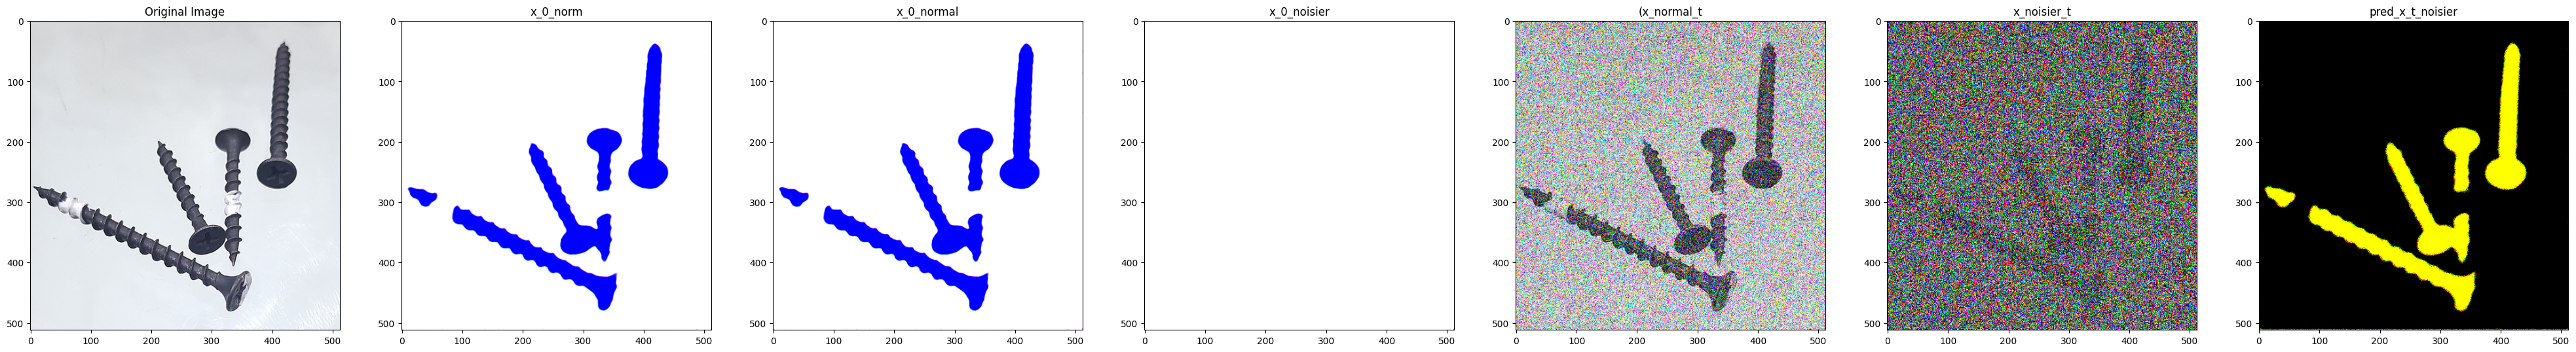

In [14]:
import matplotlib.pyplot as plt

def overlay_mask_on_image(image, mask, alpha=0.5):
    # Convert image and mask to CPU and NumPy for visualization
    image_np = image.cpu().squeeze().permute(1, 2, 0).numpy()
    mask_np = mask.cpu().squeeze().detach().numpy()
    
    # Convert mask to RGB
    mask_rgb = np.zeros_like(image_np)
    mask_rgb[..., 1] = mask_np  # Set the green channel for the mask (just an example)

    # Overlay the mask on the image
    overlay = cv2.addWeighted(image_np, alpha, mask_rgb, 1 - alpha, 0)
    
    # Visualize
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title("Overlay of Mask on Image")
    plt.show()

def overlay_mask_on_image(image, mask, alpha=0.5):
    # Convert image and mask to CPU and NumPy for visualization
    image_np = image.cpu().squeeze().permute(1, 2, 0).numpy()
    mask_np = mask.cpu().squeeze().detach().numpy()
    
    # Convert mask to RGB
    mask_rgb = np.zeros_like(image_np)
    mask_rgb[..., 1] = mask_np  # Set the green channel for the mask (just an example)

    # Overlay the mask on the image
    overlay = cv2.addWeighted(image_np, alpha, mask_rgb, 1 - alpha, 0)
    
    # Visualize
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title("Overlay of Mask on Image")
    plt.show()

def visualize_inference(image, mask, unet_model, seg_model, ddpm_sample, args, device):
    # Move image and mask to the device (GPU/CPU)
    image = image.to(device)
    mask = mask.to(device)
    
    # Normal and noisier t values
    normal_t = torch.randint(0, args["less_t_range"], (image.shape[0],), device=device)
    noisier_t = torch.randint(args["less_t_range"], ddpm_sample.num_timesteps, (image.shape[0],), device=device)
    
    # Apply norm-guided one-step denoising
    loss, pred_x_0_norm_guided, pred_x_0_normal, pred_x_0_noisier, x_normal_t, x_noisier_t, pred_x_t_noisier = ddpm_sample.norm_guided_one_step_denoising_eval(
    unet_model, image, normal_t, noisier_t, args)
    
    # Forward pass through the segmentation model
    pred_mask = seg_model(torch.cat((image, pred_x_0_norm_guided), dim=1))
    
    # Visualize the results
    plt.figure(figsize=(50, 50))
    
    # Original Image
    plt.subplot(1, 7, 1)
    plt.title('Original Image')
    plt.imshow(image.cpu().squeeze().permute(1, 2, 0).numpy())
    
    # Reconstructed Image (Anomaly-Free)
    plt.subplot(1, 7, 2)
    plt.title('x_0_norm')
    plt.imshow(pred_x_0_norm_guided.cpu().squeeze().permute(1, 2, 0).detach().numpy())
    
    # Segmentation Mask
    plt.subplot(1, 7, 3)
    plt.title('x_0_normal')
    plt.imshow(pred_x_0_normal.cpu().squeeze().permute(1, 2, 0).detach().numpy())

        # Segmentation Mask
    plt.subplot(1, 7, 4)
    plt.title('x_0_noisier')
    plt.imshow(pred_x_0_noisier.cpu().squeeze().permute(1, 2, 0).detach().numpy())

    plt.subplot(1, 7, 5)
    plt.title('(x_normal_t')
    plt.imshow(x_normal_t.cpu().squeeze().permute(1, 2, 0).detach().numpy())

    plt.subplot(1, 7, 6)
    plt.title('x_noisier_t')
    plt.imshow(x_noisier_t.cpu().squeeze().permute(1, 2, 0).detach().numpy())

    plt.subplot(1, 7, 7)
    plt.title('pred_x_t_noisier')
    plt.imshow(pred_x_t_noisier.cpu().squeeze().permute(1, 2, 0).detach().numpy())

    plt.show()

    # Overlay the mask on the image
    #overlay_mask_on_image(image, pred_mask)

def main():
    args = {
    'img_size':          512,
    'base_channels':     64,
    'dropout':           0.3,
    'num_heads':         4,
    'num_head_channels': '32,16,8',
    'lr':                1e-4,
    'Batch_Size':        4,

    'weight_decay':      0.0,
    'diffusion_lr':      1e-4,
    'seg_lr':            1e-5,

    "less_t_range":300,
    "condition_w":1,
    }
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Custom mask transformation to ensure values remain unchanged
    def mask_to_tensor(mask_image):
        mask_array = np.array(mask_image)
        mask_tensor = torch.tensor(mask_array, dtype=torch.long)
        mask_tensor = mask_tensor.unsqueeze(0)
        return mask_tensor

    # Define the transformations
    image_transform = transforms.Compose([
        transforms.ToTensor(),
        ])

    mask_transform = transforms.Compose([
        transforms.Lambda(mask_to_tensor)
    ])

    testing_dataset = ScrewDataset(image_dir=TEST_IMAGE_DIR, mask_dir=TEST_MASK_DIR, image_transform=image_transform, mask_transform=mask_transform)
    test_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False)

    testing_dataset_len = len(testing_dataset)

    # Load the saved models
    betas = get_beta_schedule(1000, 'linear')
    ddpm_sample = GaussianDiffusionModel(512, betas, loss_weight='none', loss_type='l2', noise='gauss', img_channels=3)
    unet_model = UNetModel(512, 64, dropout=0.3, n_heads=4, attention_resolutions="32,16,8", in_channels=3).to(device)
    seg_model = SegmentationSubNetwork(in_channels=6, out_channels=1).to(device)

    # Load the weights from the saved files
    unet_model.load_state_dict(torch.load('segrecons_unet_model_state_dict.pth'))
    seg_model.load_state_dict(torch.load('segrecons_seg_model_state_dict.pth'))

    # Set models to evaluation mode
    unet_model.eval()
    seg_model.eval()

    # Assuming you have a test_loader already
    for sample in test_loader:
        image = sample['image']
        mask = sample['mask']
        
        # Visualize the results
        visualize_inference(image, mask, unet_model, seg_model, ddpm_sample, args, device)
        
        
        break  # Visualize only one image, remove break to visualize more


if __name__ == '__main__':
    seed(42)
    main()

/tmp/ipykernel_95293/588737377.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model.load_state_dict(torch.load('segrecons_unet_model_state_dict.pth'))
/tmp/ipyke

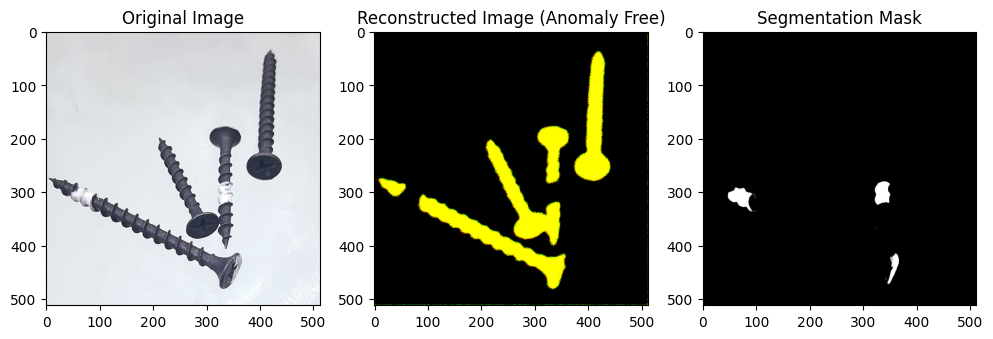

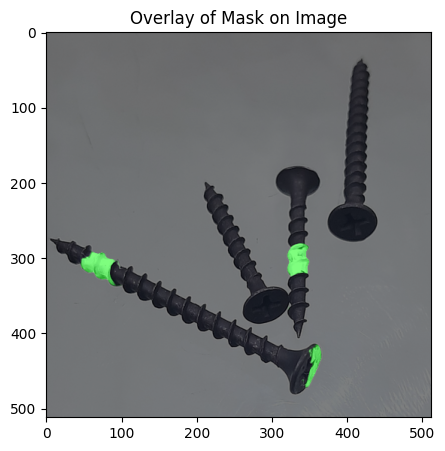

In [16]:
import matplotlib.pyplot as plt

def overlay_mask_on_image(image, mask, alpha=0.5):
    # Convert image and mask to CPU and NumPy for visualization
    image_np = image.cpu().squeeze().permute(1, 2, 0).numpy()
    mask_np = mask.cpu().squeeze().detach().numpy()
    
    # Convert mask to RGB
    mask_rgb = np.zeros_like(image_np)
    mask_rgb[..., 1] = mask_np  # Set the green channel for the mask (just an example)

    # Overlay the mask on the image
    overlay = cv2.addWeighted(image_np, alpha, mask_rgb, 1 - alpha, 0)
    
    # Visualize
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title("Overlay of Mask on Image")
    plt.show()

def visualize_inference(image, mask, unet_model, seg_model, ddpm_sample, args, device):
    # Move image and mask to the device (GPU/CPU)
    # image = image.unsqueeze(0).to(device)
    # mask = mask.unsqueeze(0).to(device)

    image = image.to(device)
    mask = mask.to(device)

    normal_t = torch.tensor([200], device=device).repeat(image.shape[0])
    noisier_t = torch.tensor([400], device=device).repeat(image.shape[0])

    # Forward pass through the reconstruction (diffusion) model
    #noise_loss, pred_x0, normal_t, x_normal_t, x_noiser_t = ddpm_sample.norm_guided_one_step_denoising_eval(unet_model, image, 1, args)
    loss, pred_x_0_norm_guided, pred_x_0_normal, pred_x_0_noisier, x_normal_t, x_noisier_t, pred_x_t_noisier = ddpm_sample.norm_guided_one_step_denoising_eval(
        unet_model, image, normal_t, noisier_t, args)
    # Forward pass through the segmentation model
    #pred_mask = seg_model(torch.cat((image, pred_x0), dim=1))
    #pred_mask = seg_model(torch.cat((image, pred_x_0_norm_guided), dim=1))
    pred_mask = seg_model(torch.cat((image, pred_x_0_normal), dim=1))
    
    
    # Visualize the results
    plt.figure(figsize=(12, 12))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(image.cpu().squeeze().permute(1, 2, 0).numpy())
    
    # Reconstruction (from diffusion model)
    plt.subplot(1, 3, 2)
    plt.title('Reconstructed Image (Anomaly Free)')
    plt.imshow(pred_x_t_noisier.cpu().squeeze().permute(1, 2, 0).detach().numpy())
    
    # Segmentation Mask
    plt.subplot(1, 3, 3)
    plt.title('Segmentation Mask')
    plt.imshow(pred_mask.cpu().squeeze().detach().numpy(), cmap='gray')

    plt.show()

    # Overlay the mask on the image
    overlay_mask_on_image(image, pred_mask)

def main():
    args = {
    'img_size':          512,
    'base_channels':     64,
    'dropout':           0.3,
    'num_heads':         4,
    'num_head_channels': '32,16,8',
    'lr':                1e-4,
    'Batch_Size':        4,

    'weight_decay':      0.0,
    'diffusion_lr':      1e-4,
    'seg_lr':            1e-5,

    "less_t_range":300,
    "condition_w":1,
    }
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Custom mask transformation to ensure values remain unchanged
    def mask_to_tensor(mask_image):
        mask_array = np.array(mask_image)
        mask_tensor = torch.tensor(mask_array, dtype=torch.long)
        mask_tensor = mask_tensor.unsqueeze(0)
        return mask_tensor

    # Define the transformations
    image_transform = transforms.Compose([
        transforms.ToTensor(),
        ])

    mask_transform = transforms.Compose([
        transforms.Lambda(mask_to_tensor)
    ])

    testing_dataset = ScrewDataset(image_dir=TEST_IMAGE_DIR, mask_dir=TEST_MASK_DIR, image_transform=image_transform, mask_transform=mask_transform)
    test_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False)

    testing_dataset_len = len(testing_dataset)

    # Load the saved models
    betas = get_beta_schedule(1000, 'linear')
    ddpm_sample = GaussianDiffusionModel(512, betas, loss_weight='none', loss_type='l2', noise='gauss', img_channels=3)
    unet_model = UNetModel(512, 64, dropout=0.3, n_heads=4, attention_resolutions="32,16,8", in_channels=3).to(device)
    seg_model = SegmentationSubNetwork(in_channels=6, out_channels=1).to(device)

    # Load the weights from the saved files
    
    unet_model.load_state_dict(torch.load('segrecons_unet_model_state_dict.pth'))
    seg_model.load_state_dict(torch.load('segrecons_seg_model_state_dict.pth'))

    # Set models to evaluation mode
    unet_model.eval()
    seg_model.eval()

    # Assuming you have a test_loader already
    for sample in test_loader:
        image = sample['image']
        mask = sample['mask']
        
        # Visualize the results
        visualize_inference(image, mask, unet_model, seg_model, ddpm_sample, args, device)
        break
        
        #break  # Visualize only one image, remove break to visualize more


if __name__ == '__main__':
    seed(42)
    main()

In [ ]:
####This loss function is used for Mulit Class Segmentation Models######
# class FocalLoss(nn.Module):
#   def __init__(self, alpha=None, gamma=4.0, reduction='mean'):
#       super(FocalLoss, self).__init__()
#       self.alpha = alpha
#       self.gamma = gamma
#       self.reduction = reduction

#   def forward(self, inputs, targets):
#       # Ensure inputs are in the form of probabilities
#       logp = F.log_softmax(inputs, dim=1)
#       # print(f'logp {logp.unique()}')
#       # print(f'logp shape {logp.shape}')
#       ce_loss = F.nll_loss(logp, targets, reduction='none')

#       #ce_loss = F.cross_entropy(inputs, targets, reduction='none')
#       # print(f'ce_loss {ce_loss.unique()}')
#       # print(f'ce_loss shape {ce_loss.shape}')
#       # Select probabilities based on target class
#       p = torch.exp(-ce_loss)
#       if self.alpha is not None:
#           alpha_t = self.alpha[targets]
#       else:
#           alpha_t = 1.0

#       # Calculate focal loss
#       loss = alpha_t * ((1 - p) ** self.gamma) * ce_loss

#       if self.reduction == 'mean':
#           return loss.mean()
#       elif self.reduction == 'sum':
#           return loss.sum()
#       else:
#           return loss

In [ ]:
# def eval2(testing_dataset_loader,args,unet_model,seg_model,data_len,device):
#     unet_model.eval()
#     seg_model.eval()
#     #os.makedirs(f'{args["output_path"]}/metrics/ARGS={args["arg_num"]}/{sub_class}/', exist_ok=True)
#     in_channels = 3

#     betas = get_beta_schedule(1000, 'linear')
#     ddpm_sample =  GaussianDiffusionModel(512, betas, loss_weight='none',loss_type='l2', noise='gauss', img_channels=in_channels)

#     total_image_pred = np.array([])
#     total_image_gt =np.array([])
#     total_pixel_gt=np.array([])
#     total_pixel_pred = np.array([])
#     tbar = tqdm(testing_dataset_loader)
#     for i, sample in enumerate(tbar):
#         image = sample["image"].to(device)
#         #target=sample['has_anomaly'].to(device)
#         target = 1
#         gt_mask = sample["mask"].to(device)

#         normal_t_tensor = torch.tensor(200, device=image.device).repeat(image.shape[0])
#         noiser_t_tensor = torch.tensor(400, device=image.device).repeat(image.shape[0])
#         loss,pred_x_0_condition,pred_x_0_normal,pred_x_0_noisier,x_normal_t,x_noiser_t,pred_x_t_noisier = ddpm_sample.norm_guided_one_step_denoising_eval(unet_model, image, normal_t_tensor,noiser_t_tensor,args)
#         pred_mask = seg_model(torch.cat((image, pred_x_0_condition), dim=1))

#         out_mask = pred_mask

#         topk_out_mask = torch.flatten(out_mask[0], start_dim=1)
#         topk_out_mask = torch.topk(topk_out_mask, 50, dim=1, largest=True)[0]
#         image_score = torch.mean(topk_out_mask)

#         total_image_pred=np.append(total_image_pred,image_score.detach().cpu().numpy())
#         #total_image_gt=np.append(total_image_gt,target[0].detach().cpu().numpy())

#         total_image_gt = np.append(total_image_gt, target)  # No indexing needed

#         flatten_pred_mask=out_mask[0].flatten().detach().cpu().numpy()
#         flatten_gt_mask =gt_mask[0].flatten().detach().cpu().numpy().astype(int)

#         total_pixel_gt=np.append(total_pixel_gt,flatten_gt_mask)
#         total_pixel_pred=np.append(total_pixel_pred,flatten_pred_mask)

#     # Check if there are multiple classes in the ground truth before calculating AUC-ROC
#     if len(np.unique(total_image_gt)) > 1:
#         auroc_image = round(roc_auc_score(total_image_gt, total_image_pred), 3) * 100
#         print("Image AUC-ROC:", auroc_image)
#     else:
#         print("Only one class present in y_true. Skipping AUC-ROC calculation.")
#         auroc_image = None

#     if len(np.unique(total_pixel_gt)) > 1:
#         auroc_pixel = round(roc_auc_score(total_pixel_gt, total_pixel_pred), 3) * 100
#         print("Pixel AUC-ROC:", auroc_pixel)
#     else:
#         print("Only one class present in pixel-level ground truth. Skipping AUC-ROC calculation.")
#         auroc_pixel = None

#     return auroc_image, auroc_pixel    

#     auroc_image = round(roc_auc_score(total_image_gt,total_image_pred),3)*100
#     print("Image AUC-ROC: " ,auroc_image)

#     auroc_pixel =  round(roc_auc_score(total_pixel_gt, total_pixel_pred),3)*100
#     print("Pixel AUC-ROC:" ,auroc_pixel)

#     return auroc_image,auroc_pixel